In [3]:
total_data.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education.num',
       'marital.status', 'occupation', 'relationship', 'race', 'sex',
       'capital.gain', 'capital.loss', 'hours.per.week', 'native.country',
       'income'],
      dtype='str')

EDA

In [16]:
# Importamos pandas para trabajar con datos en formato tabla
import pandas as pd

# Importamos numpy para operaciones numéricas
import numpy as np

# Importamos matplotlib para crear gráficos
import matplotlib.pyplot as plt

# Importamos seaborn para gráficos estadísticos más visuales
import seaborn as sns

# Cargamos el dataset desde el archivo CSV
total_data = pd.read_csv("adult-census-income.csv")

# Renombramos las columnas sustituyendo puntos por guiones bajos
# Esto evita errores al llamar columnas como hours_per_week
total_data.columns = [
    col.replace(".", "_")
    for col in total_data.columns
]

# Mostramos las primeras filas del dataset
total_data.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [17]:
# Mostramos el número de filas y columnas
print("Shape:", total_data.shape)

# Mostramos información general:
# columnas, tipos de datos y valores no nulos
total_data.info()

# Mostramos el tipo de dato de cada columna
total_data.dtypes

Shape: (32561, 15)
<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education_num   32561 non-null  int64
 5   marital_status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital_gain    32561 non-null  int64
 11  capital_loss    32561 non-null  int64
 12  hours_per_week  32561 non-null  int64
 13  native_country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


age               int64
workclass           str
fnlwgt            int64
education           str
education_num     int64
marital_status      str
occupation          str
relationship        str
race                str
sex                 str
capital_gain      int64
capital_loss      int64
hours_per_week    int64
native_country      str
income              str
dtype: object

In [19]:
# Comprobamos valores nulos por columna
print(total_data.isnull().sum())

# Buscamos valores mal codificados con "?"
# En este dataset suelen aparecer en columnas categóricas
for col in total_data.columns:

    count = (total_data[col] == "?").sum()

    if count > 0:

        print(f"{col}: {count}")

# Comprobamos registros duplicados
print("Duplicados:", total_data.duplicated().sum())


age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64
workclass: 1836
occupation: 1843
native_country: 583
Duplicados: 24


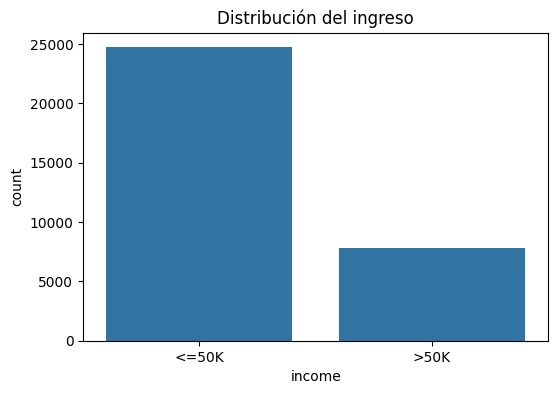

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

In [20]:
# Creamos un gráfico para ver la distribución de ingresos
plt.figure(figsize=(6,4))

sns.countplot(
    data=total_data,
    x="income"
)

plt.title("Distribución del ingreso")
plt.show()

# Mostramos el conteo exacto de cada clase
total_data["income"].value_counts()

In [21]:
# Seleccionamos las columnas numéricas del dataset
numerical_features = total_data.select_dtypes(
    include=np.number
).columns

# Mostramos las variables numéricas encontradas
print(numerical_features)

# Mostramos estadísticas descriptivas:
# media, desviación, mínimo, máximo y cuartiles
total_data[numerical_features].describe()

Index(['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss',
       'hours_per_week'],
      dtype='str')


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


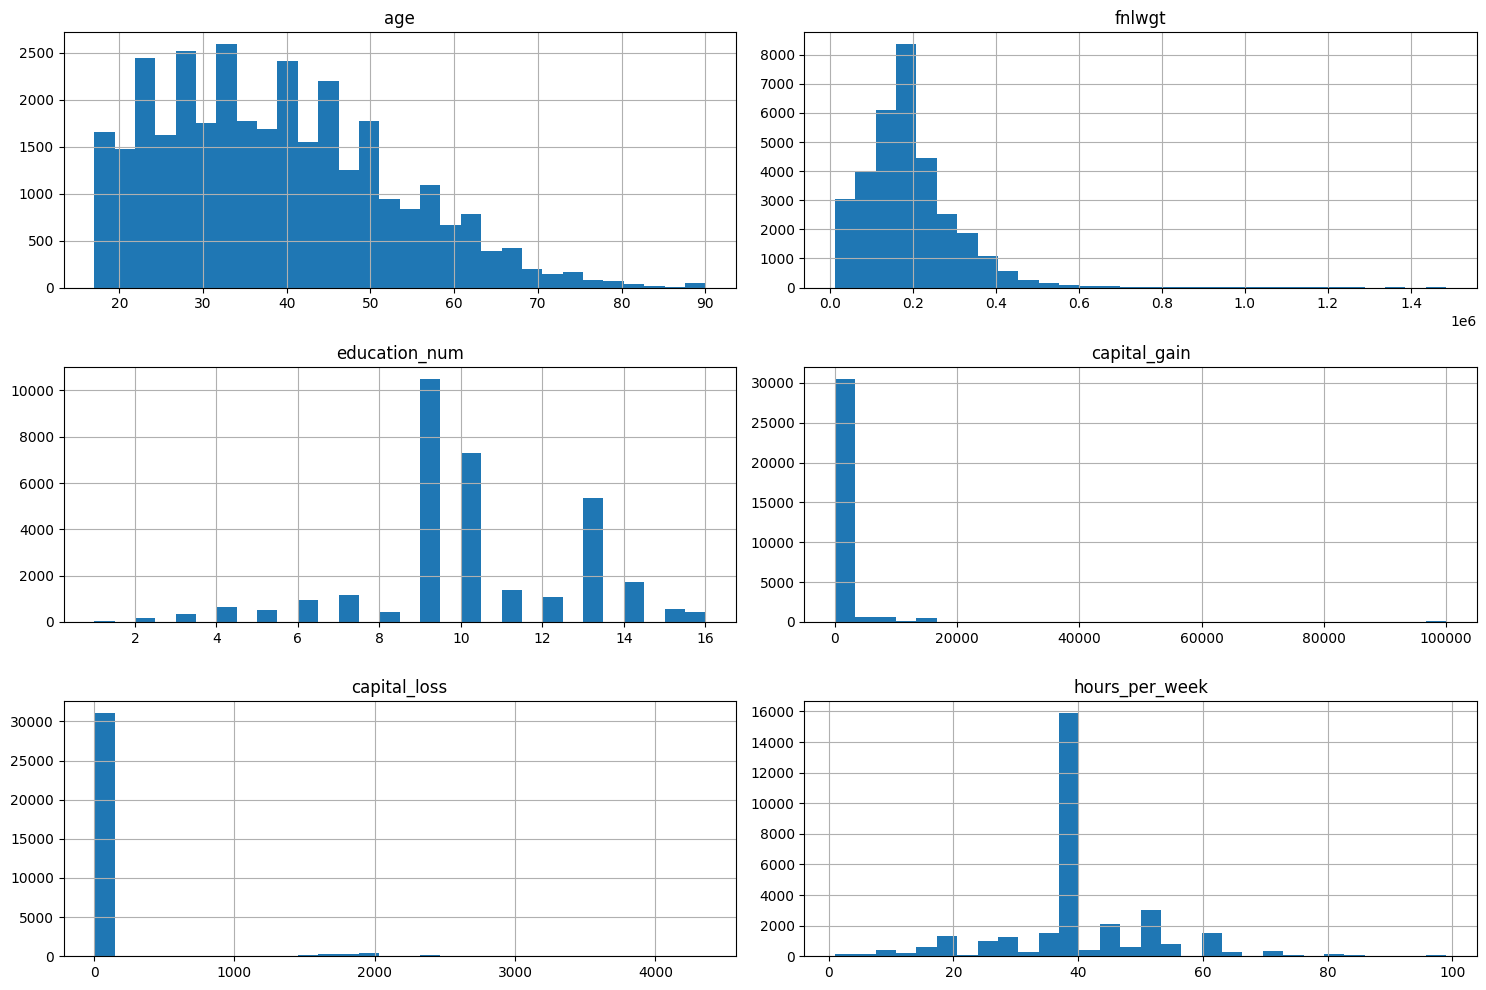

In [22]:
# Creamos histogramas para observar la distribución
# de todas las variables numéricas
total_data[numerical_features].hist(
    figsize=(15,10),
    bins=30
)

# Ajustamos el diseño para que no se solapen los gráficos
plt.tight_layout()

# Mostramos los gráficos
plt.show()

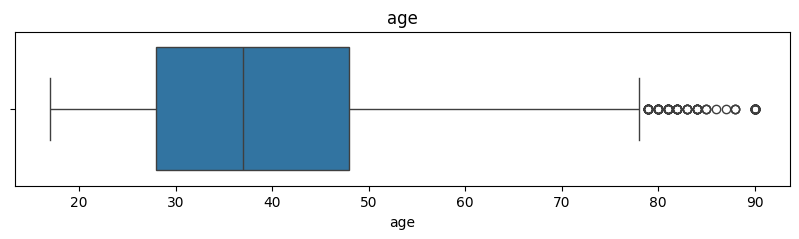

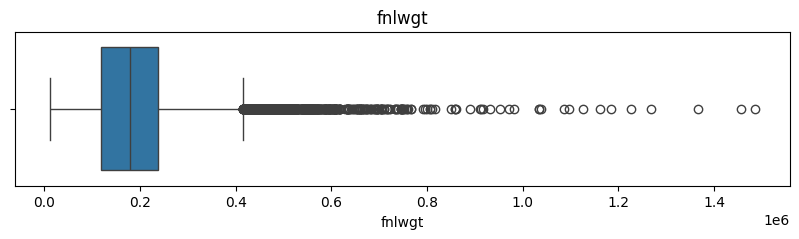

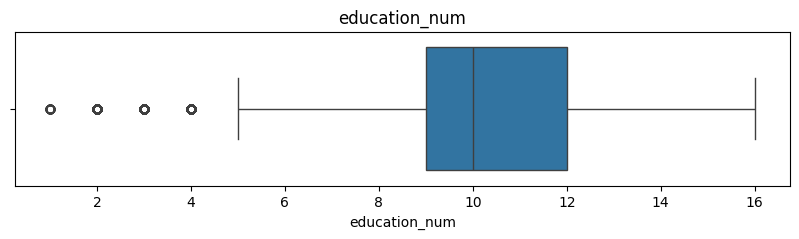

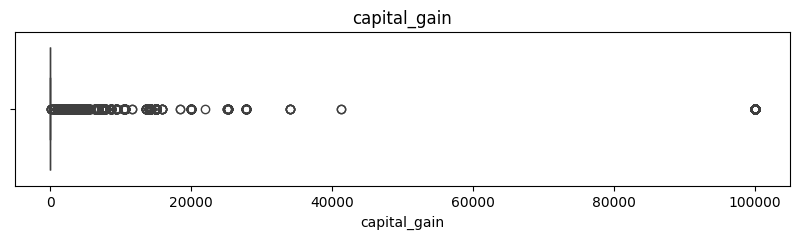

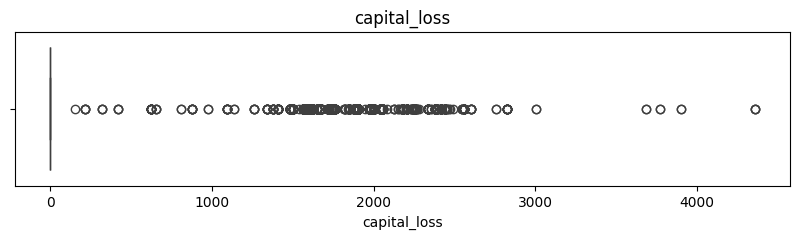

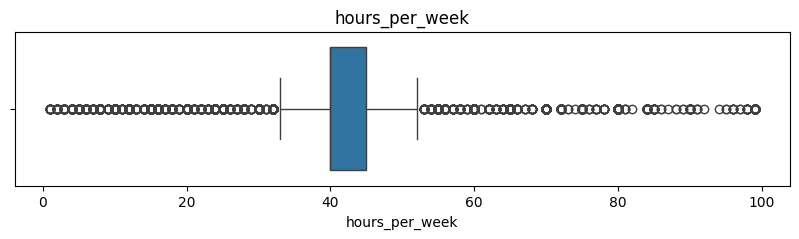

In [23]:
# Creamos un boxplot por cada variable numérica
# para detectar posibles valores atípicos

for col in numerical_features:

    plt.figure(figsize=(10,2))

    sns.boxplot(
        x=total_data[col]
    )

    plt.title(col)

    plt.show()

In [25]:
# Detectamos outliers con el método IQR

for col in numerical_features:

    # Primer cuartil
    Q1 = total_data[col].quantile(0.25)

    # Tercer cuartil
    Q3 = total_data[col].quantile(0.75)

    # Rango intercuartílico
    IQR = Q3 - Q1

    # Límite inferior
    lower = Q1 - 1.5 * IQR

    # Límite superior
    upper = Q3 + 1.5 * IQR

    # Filtramos los registros que quedan fuera de los límites
    outliers = total_data[
        (total_data[col] < lower)
        |
        (total_data[col] > upper)
    ]

    # Mostramos el número de posibles outliers
    print(f"{col}: {len(outliers)} posibles outliers")
    

age: 143 posibles outliers
fnlwgt: 992 posibles outliers
education_num: 1198 posibles outliers
capital_gain: 2712 posibles outliers
capital_loss: 1519 posibles outliers
hours_per_week: 9008 posibles outliers


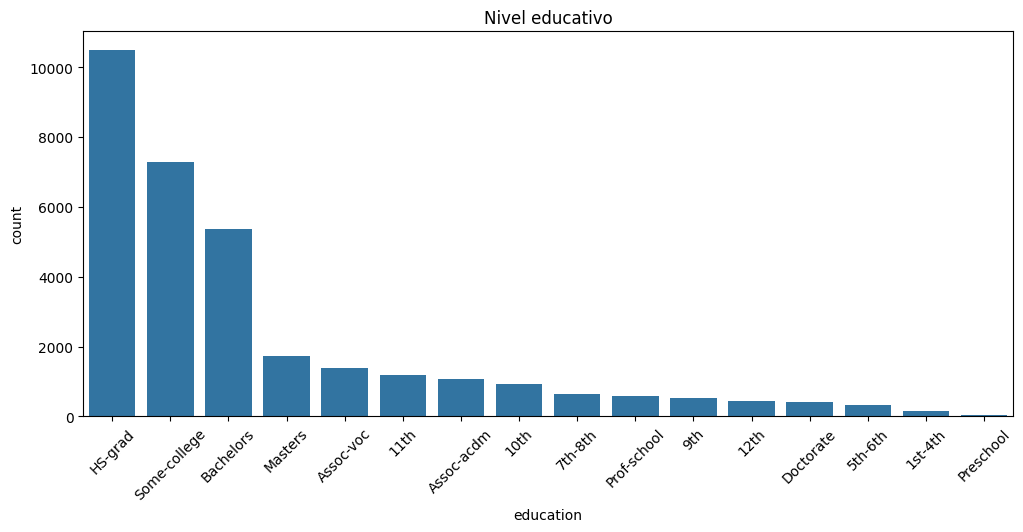

In [26]:
# Gráfico de distribución del nivel educativo
plt.figure(figsize=(12,5))

sns.countplot(
    data=total_data,
    x="education",
    order=total_data["education"].value_counts().index
)

plt.xticks(rotation=45)
plt.title("Nivel educativo")
plt.show()

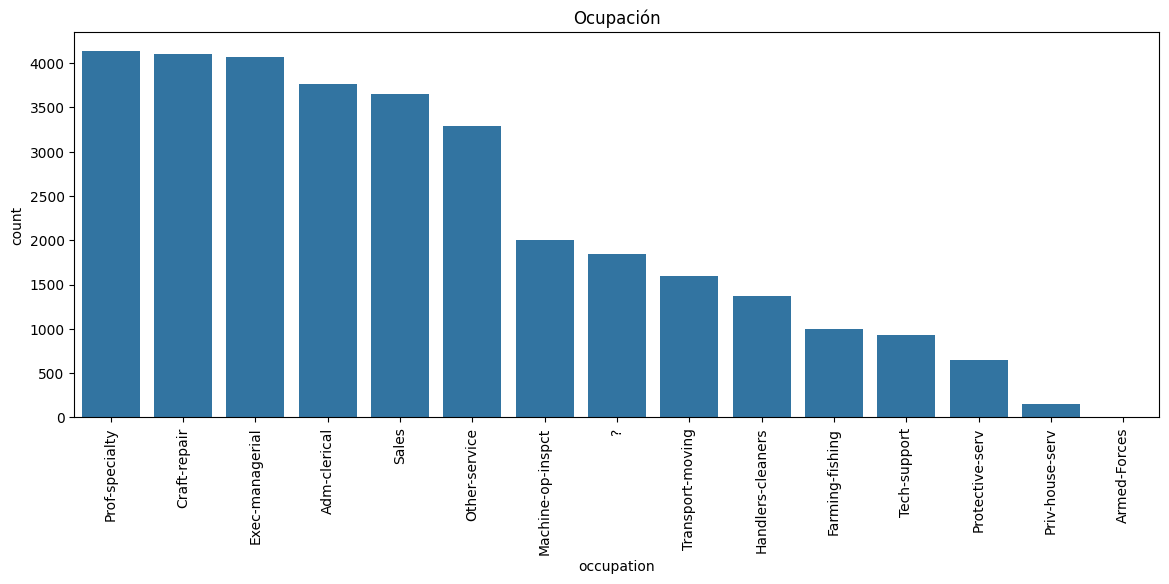

In [27]:
# Gráfico de distribución de ocupaciones
plt.figure(figsize=(14,5))

sns.countplot(
    data=total_data,
    x="occupation",
    order=total_data["occupation"].value_counts().index
)

plt.xticks(rotation=90)
plt.title("Ocupación")
plt.show()

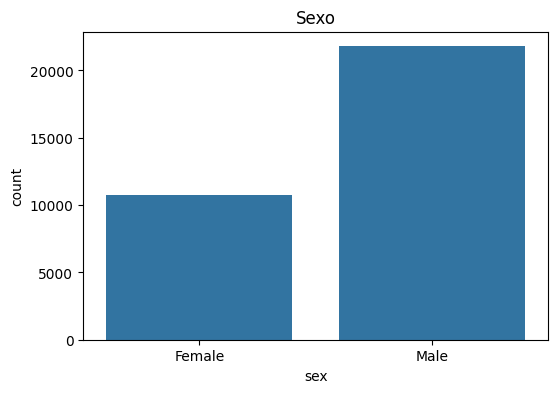

In [28]:
# Gráfico de distribución por sexo
plt.figure(figsize=(6,4))

sns.countplot(
    data=total_data,
    x="sex"
)

plt.title("Sexo")
plt.show()

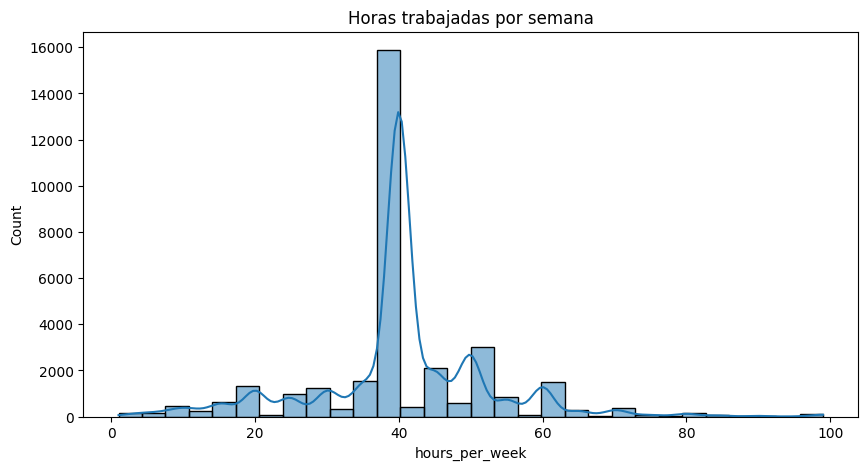

In [29]:
# Histograma de horas trabajadas por semana
plt.figure(figsize=(10,5))

sns.histplot(
    total_data["hours_per_week"],
    bins=30,
    kde=True
)

plt.title("Horas trabajadas por semana")
plt.show()

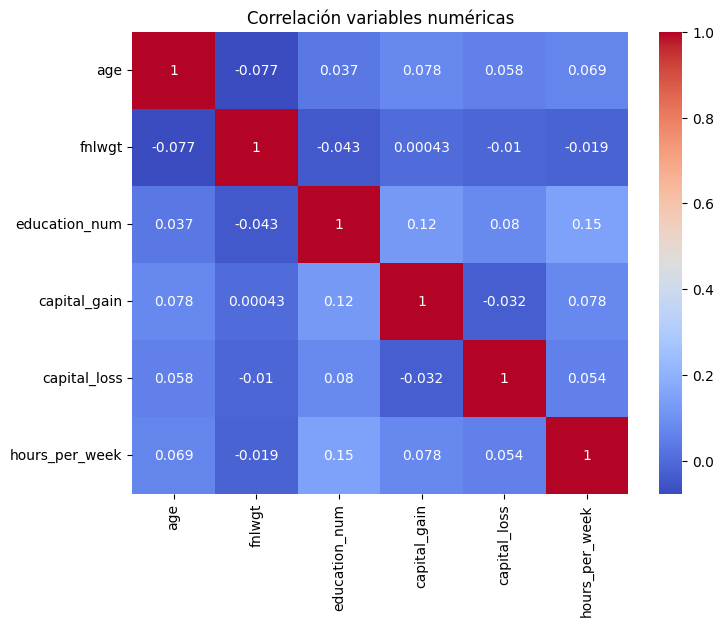

In [30]:
# Creamos una matriz de correlación
# entre las variables numéricas
plt.figure(figsize=(8,6))

sns.heatmap(
    total_data[numerical_features].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlación variables numéricas")
plt.show()

# Conclusiones del EDA

Se realizó un análisis exploratorio del dataset Adult Census Income para comprender su estructura y la calidad de sus datos.

En primer lugar, se revisaron las dimensiones del conjunto de datos, los tipos de variables, los valores nulos, los posibles valores mal codificados y los registros duplicados. También se analizó la distribución de la variable objetivo `income`, que indica si una persona gana más o menos de 50.000 dólares anuales.

Posteriormente, se estudiaron las variables numéricas mediante estadísticas descriptivas, histogramas y diagramas de caja. Se detectaron posibles valores atípicos en variables como `capital_gain`, `capital_loss`, `fnlwgt` y `hours_per_week`. Estos valores no se eliminarán inicialmente, ya que pueden representar situaciones reales dentro de la población y aportar información útil al modelo.

También se analizaron variables categóricas importantes como `education`, `occupation` y `sex`, ya que pueden tener relación con el nivel de ingresos y serán relevantes para el sistema de recomendación.

Finalmente, se revisó la correlación entre variables numéricas para identificar posibles relaciones entre ellas. Tras este análisis, el dataset queda preparado para la fase de limpieza, transformación de variables y construcción del modelo predictivo.

In [31]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [32]:
# =========================
# LIMPIEZA DE DATOS
# =========================

# Sustituimos los valores '?'
# por valores nulos

total_data.replace(
    "?",
    pd.NA,
    inplace=True
)

# Eliminamos filas con nulos

total_data.dropna(
    inplace=True
)

# Limpiamos espacios
# de la variable objetivo

total_data["income"] = (
    total_data["income"]
    .str.strip()
)

# Creamos variable binaria

total_data["high_income"] = (

    total_data["income"]

    .apply(
        lambda x:
        1 if x == ">50K"
        else 0
    )

)

total_data.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,high_income
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K,0
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K,0
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K,0
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K,0
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K,0


In [33]:
# =========================
# SELECCIÓN DE VARIABLES
# =========================

# Seleccionamos las variables
# que utilizaremos para predecir
# si una persona gana más de 50K

features = [

    "age",

    "education",

    "marital_status",

    "occupation",

    "hours_per_week",

    "sex",

    "native_country"

]

# Variables predictoras

X = total_data[
    features
]

# Variable objetivo

y = total_data[
    "high_income"
]

# =========================
# VARIABLES NUMÉRICAS
# =========================

numeric_features = [

    "age",

    "hours_per_week"

]

# =========================
# VARIABLES CATEGÓRICAS
# =========================

categorical_features = [

    "education",

    "marital_status",

    "occupation",

    "sex",

    "native_country"

]

# =========================
# TRANSFORMACIÓN NUMÉRICA
# =========================

# Escalamos las variables numéricas

# Esto evita que una variable
# tenga más peso que otra
# por tener valores más grandes

from sklearn.preprocessing import StandardScaler

numeric_transformer = StandardScaler()

# =========================
# TRANSFORMACIÓN CATEGÓRICA
# =========================

# Convertimos categorías
# en variables numéricas

# Ejemplo:
# Male -> 1,0
# Female -> 0,1

from sklearn.preprocessing import OneHotEncoder

categorical_transformer = OneHotEncoder(

    handle_unknown = "ignore"

)

# =========================
# PREPROCESADOR
# =========================

# Aplicamos ambas transformaciones

# StandardScaler:
# variables numéricas

# OneHotEncoder:
# variables categóricas

from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(

    transformers = [

        (

            "num",

            numeric_transformer,

            numeric_features

        ),

        (

            "cat",

            categorical_transformer,

            categorical_features

        )

    ]

)

# Mostrar variables seleccionadas

print(X.head())

   age     education marital_status         occupation  hours_per_week  \
1   82       HS-grad        Widowed    Exec-managerial              18   
3   54       7th-8th       Divorced  Machine-op-inspct              40   
4   41  Some-college      Separated     Prof-specialty              40   
5   34       HS-grad       Divorced      Other-service              45   
6   38          10th      Separated       Adm-clerical              40   

      sex native_country  
1  Female  United-States  
3  Female  United-States  
4  Female  United-States  
5  Female  United-States  
6    Male  United-States  


In [35]:
# =========================
# CREACIÓN DEL PIPELINE
# =========================

# Un Pipeline permite encadenar
# varias etapas de procesamiento
# y entrenamiento en un único objeto.

# Primero se aplicará el preprocesamiento:
# - StandardScaler para variables numéricas
# - OneHotEncoder para variables categóricas

# Después se entrenará el clasificador.

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

model = Pipeline(

    steps = [

        # Aplicar transformaciones
        # definidas anteriormente

        (
            "preprocessor",
            preprocessor
        ),

        # Modelo de clasificación

        (
            "classifier",

            LogisticRegression(

                max_iter = 1000

            )

        )

    ]

)

# =========================
# DIVISIÓN TRAIN / TEST
# =========================

# Dividimos los datos en:

# 80% entrenamiento
# 20% prueba

# El conjunto de entrenamiento
# servirá para aprender patrones.

# El conjunto de prueba
# servirá para evaluar
# el rendimiento real.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size = 0.20,

    random_state = 42

)

# =========================
# ENTRENAMIENTO DEL MODELO
# =========================

# El modelo aprende la relación
# entre las características
# del usuario y su nivel de ingresos.

model.fit(

    X_train,

    y_train

)



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['age','education','marital_status',...,'hours_per_week','sex', 'native_country']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthr

In [36]:
# =========================
# SISTEMA DE RECOMENDACIÓN
# =========================

def recommend_trajectory(user_profile):

    """
    user_profile debe contener:

    - age
    - education
    - marital_status
    - occupation
    - hours_per_week
    - sex
    - native_country

    """

    # =========================
    # CONVERTIR PERFIL A DATAFRAME
    # =========================

    # El modelo espera recibir
    # los datos en formato DataFrame

    user_df = pd.DataFrame(

        [user_profile]

    )

    # =========================
    # PREDICCIÓN
    # =========================

    # 0 = <=50K

    # 1 = >50K

    prediction = model.predict(

        user_df

    )[0]

    # =========================
    # PROBABILIDAD
    # =========================

    # Obtenemos la probabilidad
    # de pertenecer a la clase >50K

    prob = model.predict_proba(

        user_df

    )[0][1]

    # =========================
    # RECOMENDACIÓN
    # =========================

    if prediction == 1:

        return (

            f"✅ Con este perfil, "

            f"tu probabilidad de ganar "

            f"más de 50K es del "

            f"{prob*100:.1f}%."

        )

    else:

        return (

            f"⚠️ Con este perfil, "

            f"tu probabilidad de superar "

            f"los 50K es solo del "

            f"{prob*100:.1f}%.\n\n"

            f"Recomendación:\n"

            f"- Mejorar el nivel educativo.\n"

            f"- Buscar ocupaciones con "

            f"mayor remuneración.\n"

            f"- Incrementar experiencia "

            f"y horas trabajadas "

            f"si es posible."

        )

In [37]:
# =========================
# USUARIO SIMULADO
# =========================

simulated_user = {

    "age": 25,

    "education": "HS-grad",

    "marital_status": "Never-married",

    "occupation": "Sales",

    "hours_per_week": 30,

    "sex": "Male",

    "native_country": "United-States"

}

# Obtener recomendación

print(

    recommend_trajectory(

        simulated_user

    )

)

⚠️ Con este perfil, tu probabilidad de superar los 50K es solo del 2.0%.

Recomendación:
- Mejorar el nivel educativo.
- Buscar ocupaciones con mayor remuneración.
- Incrementar experiencia y horas trabajadas si es posible.


In [38]:
# =========================
# GUARDAR MODELO
# =========================

# Importamos librerías

import os
import joblib

# Creamos la carpeta models
# si no existe

os.makedirs(
    "../models",
    exist_ok=True
)

# Guardamos el pipeline completo

joblib.dump(

    model,

    "../models/adult_income_recommender.pkl"

)

print(
    "Modelo guardado correctamente."
)

Modelo guardado correctamente.


In [39]:
# =========================
# PRUEBAS CON USUARIOS SIMULADOS
# =========================

# Usuario 1:
# joven, estudios secundarios,
# trabaja pocas horas

user_1 = {
    "age": 25,
    "education": "HS-grad",
    "marital_status": "Never-married",
    "occupation": "Sales",
    "hours_per_week": 30,
    "sex": "Male",
    "native_country": "United-States"
}

# Usuario 2:
# adulto, estudios universitarios,
# ocupación profesional

user_2 = {
    "age": 40,
    "education": "Bachelors",
    "marital_status": "Married-civ-spouse",
    "occupation": "Prof-specialty",
    "hours_per_week": 45,
    "sex": "Female",
    "native_country": "United-States"
}

# Usuario 3:
# adulto, máster,
# cargo ejecutivo

user_3 = {
    "age": 45,
    "education": "Masters",
    "marital_status": "Married-civ-spouse",
    "occupation": "Exec-managerial",
    "hours_per_week": 50,
    "sex": "Male",
    "native_country": "United-States"
}

# Ejecutamos recomendaciones

print("Usuario 1:")
print(recommend_trajectory(user_1))

print("\nUsuario 2:")
print(recommend_trajectory(user_2))

print("\nUsuario 3:")
print(recommend_trajectory(user_3))

Usuario 1:
⚠️ Con este perfil, tu probabilidad de superar los 50K es solo del 2.0%.

Recomendación:
- Mejorar el nivel educativo.
- Buscar ocupaciones con mayor remuneración.
- Incrementar experiencia y horas trabajadas si es posible.

Usuario 2:
✅ Con este perfil, tu probabilidad de ganar más de 50K es del 67.1%.

Usuario 3:
✅ Con este perfil, tu probabilidad de ganar más de 50K es del 86.5%.


## Pruebas con usuarios simulados

Se crearon distintos perfiles hipotéticos para comprobar el funcionamiento del sistema de recomendación.

Cada perfil modifica variables como edad, nivel educativo, ocupación, estado civil y horas trabajadas por semana.

El objetivo es observar cómo cambia la probabilidad estimada de superar los 50.000 dólares anuales según las características socioeconómicas del usuario.

# Conclusión

En este proyecto se desarrolló un sistema de recomendación basado en datos socioeconómicos obtenidos del conjunto de datos Adult Census Income. El objetivo principal fue predecir si una persona tiene probabilidades de superar los 50.000 dólares anuales de ingresos y, posteriormente, generar recomendaciones personalizadas que ayuden a mejorar dicha probabilidad.

En primer lugar, se realizó un análisis exploratorio de los datos (EDA), identificando la estructura del conjunto de datos, posibles valores nulos, registros duplicados, variables categóricas y numéricas, así como la presencia de valores atípicos. Este análisis permitió comprender mejor las características de la población estudiada y preparar adecuadamente los datos para el modelado.

Posteriormente, se llevó a cabo una fase de preprocesamiento que incluyó la limpieza de valores faltantes, la codificación de variables categóricas mediante OneHotEncoder y la normalización de variables numéricas mediante StandardScale. Estas transformaciones se integraron en un Pipeline, garantizando un flujo de trabajo ordenado y reproducible.

A continuación, se entrenó un modelo de Regresión Logística, capaz de estimar la probabilidad de que una persona pertenezca al grupo de ingresos superiores a 50.000 dólares anuales. El modelo fue entrenado utilizando una división de entrenamiento y prueba, permitiendo evaluar su capacidad predictiva sobre datos no vistos.

Finalmente, se construyó un sistema de recomendación interpretativo que utiliza las predicciones del modelo para proporcionar orientación personalizada a usuarios simulados. El sistema analiza características como la educación, ocupación, edad, sexo, estado civil y horas trabajadas por semana para estimar las posibilidades de alcanzar mayores ingresos y sugerir posibles acciones de mejora.

Los resultados obtenidos muestran que variables como el nivel educativo, la ocupación desempeñada y la dedicación laboral tienen una influencia significativa sobre la probabilidad de superar el umbral de ingresos estudiado. De esta forma, el proyecto demuestra cómo las técnicas de Machine Learning pueden utilizarse no solo para predecir resultados futuros, sino también para generar recomendaciones útiles y comprensibles para la toma de decisiones.

Por último, el modelo fue almacenado para su reutilización futura, permitiendo aplicar el sistema de recomendación a nuevos perfiles sin necesidad de volver a entrenarlo.